In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import multivariate_t
import matplotlib.pyplot as plt

tickers=['AAPL', 'JPM', 'LMT', 'XOM']         # AAPL- apple, JPM- JP Morgan, LMT- Lockheed Martin, XOM- ExxonMobil

print('Fetching latest market logs ')

rawdata= yf.download(tickers, start='2023-01-01', end='2026-07-01')['Close']

Fetching latest market logs 


/tmp/ipykernel_924/3403622771.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rawdata= yf.download(tickers, start='2023-01-01', end='2026-07-01')['Close']
[*********************100%***********************]  4 of 4 completed


In [3]:
dailyreturn= rawdata.pct_change().dropna()

meanreturn= dailyreturn.mean()
covmatrix= dailyreturn.cov()
corrmatrix= dailyreturn.corr()


print("\nMean daily Returns: \n")
print(meanreturn)
print("\nCovariance Matrix: \n")
print(covmatrix)
print('\nCo-relation Matrix')
print(corrmatrix)


Mean daily Returns: 

Ticker
AAPL    0.001109
JPM     0.001216
LMT     0.000281
XOM     0.000531
dtype: float64

Covariance Matrix: 

Ticker          AAPL       JPM           LMT       XOM
Ticker                                                
AAPL    2.609333e-04  0.000069 -3.183064e-07  0.000030
JPM     6.857651e-05  0.000215  3.153474e-05  0.000057
LMT    -3.183064e-07  0.000032  1.987977e-04  0.000047
XOM     2.959851e-05  0.000057  4.693714e-05  0.000223

Co-relation Matrix
Ticker      AAPL       JPM       LMT       XOM
Ticker                                        
AAPL    1.000000  0.289860 -0.001398  0.122616
JPM     0.289860  1.000000  0.152708  0.259134
LMT    -0.001398  0.152708  1.000000  0.222769
XOM     0.122616  0.259134  0.222769  1.000000


# Simulating 10000 times for a time period of 30 dyas to get possible return amounts

In [4]:
num_simulation=10000
time_horizon=30       #next 30 days prediction
initial_investment=10000    #starting with 10000


weights_eq = np.array([0.25,0.25,0.25,0.25])

simulation_results= np.zeros(num_simulation)

df=10

print(f'Running {num_simulation} simulated futures over {time_horizon} days\n')


for i in range(num_simulation):

  simulated_returns = multivariate_t.rvs(loc=meanreturn,shape=covmatrix, df=df, size=time_horizon)

  portfolio_daily_ret= np.dot(simulated_returns, weights_eq)

  final_value = initial_investment *np.prod(1+portfolio_daily_ret)

  simulation_results[i]=final_value

print('Simulation Complete\n The ending values of the first five alternate timelines: ')
print(np.round(simulation_results[:5],2))

Running 10000 simulated futures over 30 days

Simulation Complete
 The ending values of the first five alternate timelines: 
[10106.93 10737.2   9784.2  10643.86  9131.17]


# Visualising and giving insight from the possibilities

95% Value at Risk (VaR): $696.11
Business Translation: We are 95% confident that this portfolio will not drop below $9303.89 over the next 30 days.



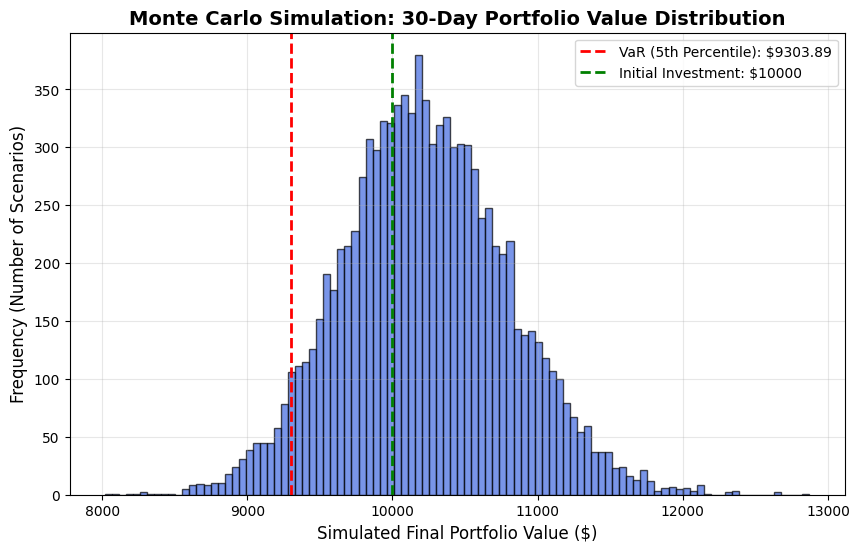

In [5]:
percentile_5 =np.percentile(simulation_results, 5)

var_95= initial_investment-percentile_5

print(f"95% Value at Risk (VaR): ${var_95:.2f}")
print(f"Business Translation: We are 95% confident that this portfolio will not drop below ${percentile_5:.2f} over the next {time_horizon} days.\n")


plt.figure(figsize=(10, 6))
plt.hist(simulation_results, bins=100, color='royalblue', edgecolor='black', alpha=0.7)


plt.axvline(percentile_5, color='red', linestyle='dashed', linewidth=2, label=f'VaR (5th Percentile): ${percentile_5:.2f}')
plt.axvline(initial_investment, color='green', linestyle='dashed', linewidth=2, label=f'Initial Investment: ${initial_investment}')


plt.title(f'Monte Carlo Simulation: {time_horizon}-Day Portfolio Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Simulated Final Portfolio Value ($)', fontsize=12)
plt.ylabel('Frequency (Number of Scenarios)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optimizing Weights for a Financial Year

In [6]:
num_portfolios=5000     # number of different combinations of stocks to check
all_weights= np.zeros((num_portfolios, len(tickers)))
return_arr=np.zeros (num_portfolios)
vol_arr= np.zeros(num_portfolios)
sharpe_arr= np.zeros(num_portfolios)

risk_free_rate =0.04    #like US standard treasury bond

for x in range(num_portfolios):
  weights= np.array(np.random.random(len(tickers)))
  weights =weights/ np.sum(weights)
  all_weights[x, :]= weights

  return_arr[x]=np.sum((meanreturn*weights)*252)      #assuming 252 trading days in a year for US markets

  vol_arr[x]=np.sqrt(np.dot(weights.T, np.dot(covmatrix, weights))) *np.sqrt(252)

  sharpe_arr[x]= (return_arr[x]-risk_free_rate)/vol_arr[x]


max_sharpe_id= sharpe_arr.argmax()
optimal_return =return_arr[max_sharpe_id]
optimal_volatility = vol_arr[max_sharpe_id]
optimal_weights = all_weights[max_sharpe_id, :]

print(f"\nExpected Annual Return: {optimal_return:.2%}")
print(f"\nAnnual Volatility (Risk): {optimal_volatility:.2%}")
print(f"\nMaximum Sharpe Ratio: {sharpe_arr[max_sharpe_id]:.2f}\n")

print("Target Asset Allocation:")
for i in range(len(tickers)):
    print(f"{tickers[i]}: {optimal_weights[i]:.2%}")


Expected Annual Return: 28.16%

Annual Volatility (Risk): 18.48%

Maximum Sharpe Ratio: 1.31

Target Asset Allocation:
AAPL: 36.57%
JPM: 55.67%
LMT: 2.47%
XOM: 5.29%


# Calculating VaR from the Optimal Weights found

In [7]:
num_simulation=10000
time_horizon=30       #next 30 days prediction
initial_investment=10000    #starting with 10000


weights = optimal_weights

simulation_results= np.zeros(num_simulation)

print(f'Running {num_simulation} simulated futures over {time_horizon} days\n')


for i in range(num_simulation):

  simulated_returns = multivariate_t.rvs(loc=meanreturn,shape=covmatrix, df=df, size=time_horizon)

  portfolio_daily_ret= np.dot(simulated_returns, weights)

  final_value = initial_investment *np.prod(1+portfolio_daily_ret)

  simulation_results[i]=final_value

print('Simulation Complete\n The ending values of the first five alternate timelines: ')
print(np.round(simulation_results[:5],2))

Running 10000 simulated futures over 30 days

Simulation Complete
 The ending values of the first five alternate timelines: 
[10133.51 11335.27 10274.94 11294.2  11471.14]


95% Value at Risk (VaR): $804.30
Business Translation: We are 95% confident that this portfolio will not drop below $9195.70 over the next 30 days.



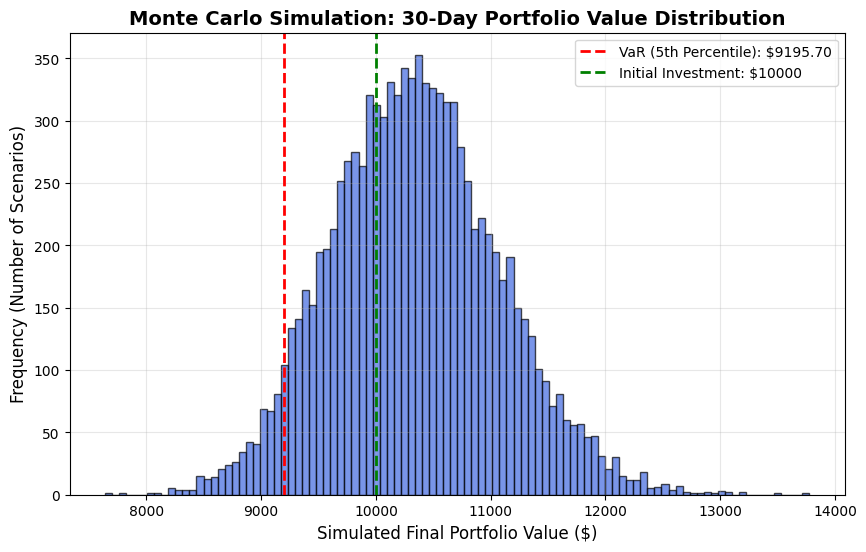

In [8]:
percentile_5 =np.percentile(simulation_results, 5)

var_95= initial_investment-percentile_5

print(f"95% Value at Risk (VaR): ${var_95:.2f}")
print(f"Business Translation: We are 95% confident that this portfolio will not drop below ${percentile_5:.2f} over the next {time_horizon} days.\n")


plt.figure(figsize=(10, 6))
plt.hist(simulation_results, bins=100, color='royalblue', edgecolor='black', alpha=0.7)


plt.axvline(percentile_5, color='red', linestyle='dashed', linewidth=2, label=f'VaR (5th Percentile): ${percentile_5:.2f}')
plt.axvline(initial_investment, color='green', linestyle='dashed', linewidth=2, label=f'Initial Investment: ${initial_investment}')


plt.title(f'Monte Carlo Simulation: {time_horizon}-Day Portfolio Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Simulated Final Portfolio Value ($)', fontsize=12)
plt.ylabel('Frequency (Number of Scenarios)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# OOP Approach

In [9]:
# --- OOP REFACTOR: THE QUANTITATIVE ENGINE ---
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_t

class QuantitativeEngine:
    def __init__(self, tickers, start_date, end_date):
        """Initializes the engine and automatically fetches the market DNA."""
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date

        print(f"Initializing Quantitative Engine for {len(tickers)} assets...")
        self.raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
        self.daily_returns = self.raw_data.pct_change().dropna()
        self.mean_returns = self.daily_returns.mean()
        self.cov_matrix = self.daily_returns.cov()
        print("Market DNA successfully extracted.\n")

    def optimize_portfolio(self, num_portfolios=5000, risk_free_rate=0.04):
        """Runs the Markowitz Efficient Frontier to find the optimal Sharpe Ratio."""
        print(f"Running {num_portfolios} MPT simulations...")
        all_weights = np.zeros((num_portfolios, len(self.tickers)))
        ret_arr = np.zeros(num_portfolios)
        vol_arr = np.zeros(num_portfolios)
        sharpe_arr = np.zeros(num_portfolios)

        # To ensure reproducible results
        np.random.seed(4)

        for x in range(num_portfolios):
            weights = np.array(np.random.random(len(self.tickers)))
            weights = weights / np.sum(weights)
            all_weights[x, :] = weights

            ret_arr[x] = np.sum((self.mean_returns * weights) * 252)
            vol_arr[x] = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights))) * np.sqrt(252)
            sharpe_arr[x] = (ret_arr[x] - risk_free_rate) / vol_arr[x]

        max_sharpe_idx = sharpe_arr.argmax()
        self.optimal_weights = all_weights[max_sharpe_idx, :]

        print("--- Optimization Complete ---")
        print(f"Expected Return: {ret_arr[max_sharpe_idx]:.2%}")
        print(f"Volatility: {vol_arr[max_sharpe_idx]:.2%}")
        return self.optimal_weights

    def run_monte_carlo(self, weights, time_horizon=30, initial_investment=10000, num_simulations=10000):
        """Stress tests a specific set of weights over a set time horizon."""
        print(f"\nRunning {num_simulations} Monte Carlo simulations over {time_horizon} days...")
        simulation_results = np.zeros(num_simulations)

        np.random.seed(4)

        df = 10
        for i in range(num_simulations):

            simulated_returns = multivariate_t.rvs(loc=meanreturn,shape=covmatrix, df=df, size=time_horizon)
            portfolio_daily_ret = np.dot(simulated_returns, weights)
            final_value = initial_investment * np.prod(1 + portfolio_daily_ret)
            simulation_results[i] = final_value

        percentile_5 = np.percentile(simulation_results, 5)
        var_95 = initial_investment - percentile_5

        print(f"95% Value at Risk (VaR): ${var_95:.2f}")
        return simulation_results, var_95

# ==========================================
# --- HOW TO USE THE CLASS (THE EXECUTION) ---
# ==========================================

# 1. Instantiate the Engine
my_portfolio = QuantitativeEngine(
    tickers=['AAPL', 'JPM', 'LMT', 'XOM'],
    start_date='2023-01-01',
    end_date='2026-07-01'
)

# 2. Get the optimal weights
best_weights = my_portfolio.optimize_portfolio()

# 3. Stress test the optimal weights
results, portfolio_var = my_portfolio.run_monte_carlo(weights=best_weights)

/tmp/ipykernel_924/584370924.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed

Initializing Quantitative Engine for 4 assets...
Market DNA successfully extracted.

Running 5000 MPT simulations...


--- Optimization Complete ---
Expected Return: 29.04%
Volatility: 19.15%

Running 10000 Monte Carlo simulations over 30 days...
95% Value at Risk (VaR): $831.10


# Backtesting

In [10]:
# Training on Data from 2023 till 2025

train_engine = QuantitativeEngine(
    tickers=['AAPL', 'JPM', 'LMT', 'XOM'],
    start_date='2023-01-01',
    end_date='2025-12-31'
)

# Finding optimal Weights
optimal_train_weights = train_engine.optimize_portfolio(num_portfolios=5000)

Initializing Quantitative Engine for 4 assets...


/tmp/ipykernel_924/584370924.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed


Market DNA successfully extracted.

Running 5000 MPT simulations...
--- Optimization Complete ---
Expected Return: 32.05%
Volatility: 19.19%


In [11]:
# Testing on Data from January till june of 2026


test_engine = QuantitativeEngine(
    tickers=['AAPL', 'JPM', 'LMT', 'XOM'],
    start_date='2026-01-01',
    end_date='2026-07-01'
)


test_returns = test_engine.daily_returns

# Using optimal Weights to get daily returns for portfolio
algo_daily_returns = np.dot(test_returns, optimal_train_weights)

# Using equally distributed portfolio to get daily net return of portfolio
benchmark_weights = np.array([0.25, 0.25, 0.25, 0.25])
benchmark_daily_returns = np.dot(test_returns, benchmark_weights)

Initializing Quantitative Engine for 4 assets...


/tmp/ipykernel_924/584370924.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed

Market DNA successfully extracted.



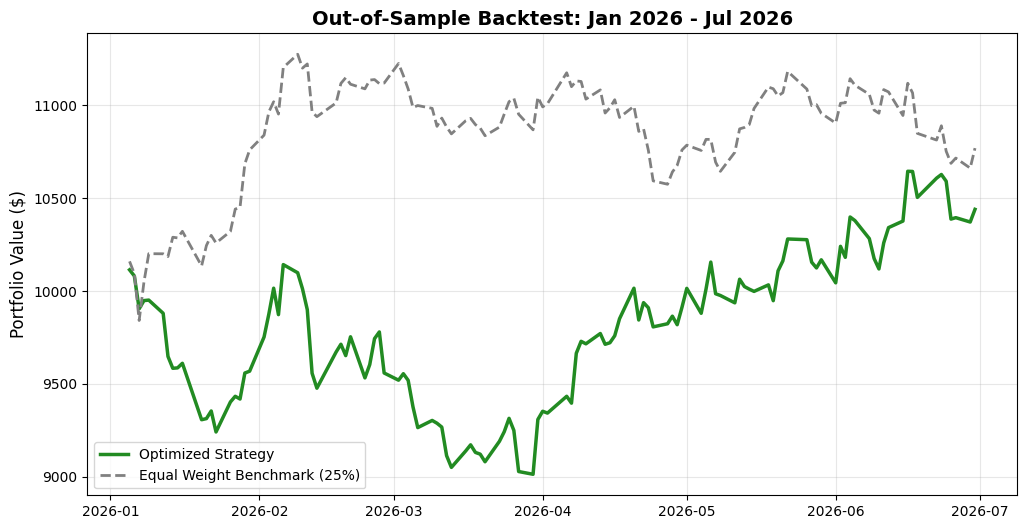


--- Final Test Results (July 2026) ---
Algorithm Final Value: $10439.36
Benchmark Final Value: $10768.88


In [12]:


#Calculate snowballing compound interest (Starting with a $10,000 baseline)
algo_cumulative = 10000 * np.cumprod(1 + algo_daily_returns)
benchmark_cumulative = 10000 * np.cumprod(1 + benchmark_daily_returns)


plt.figure(figsize=(12, 6))
plt.plot(test_returns.index, algo_cumulative, label='Optimized Strategy', color='forestgreen', linewidth=2.5)
plt.plot(test_returns.index, benchmark_cumulative, label='Equal Weight Benchmark (25%)', color='gray', linestyle='dashed', linewidth=2)

plt.title('Out-of-Sample Backtest: Jan 2026 - Jul 2026', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print(f"\n--- Final Test Results (July 2026) ---")
print(f"Algorithm Final Value: ${algo_cumulative[-1]:.2f}")
print(f"Benchmark Final Value: ${benchmark_cumulative[-1]:.2f}")

In [13]:
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from quant_engine import QuantitativeEngine

# --- 1. UI Setup & Header ---
st.set_page_config(page_title="Quant Portfolio Optimizer", layout="wide")
st.title("📈 Algorithmic Portfolio Optimizer & Risk Engine")
st.markdown("Enter your preferred stock tickers to mathematically calculate the optimal Sharpe Ratio weights and stress-test the portfolio.")

# --- 2. Dynamic User Inputs (Sidebar) ---
st.sidebar.header("Engine Parameters")

# --- NEW UX FEATURE: TICKER CHEAT SHEET ---
with st.sidebar.expander("📚 Common Ticker Reference"):
    st.markdown("""
    **Technology**
    * **AAPL:** Apple
    * **MSFT:** Microsoft
    * **GOOGL:** Google
    * **NVDA:** Nvidia
    * **META:** Meta (Facebook)

    **Finance & Banking**
    * **JPM:** JPMorgan Chase
    * **BAC:** Bank of America
    * **V:** Visa

    **Energy & Defense**
    * **XOM:** ExxonMobil
    * **CVX:** Chevron
    * **LMT:** Lockheed Martin

    **Consumer & Retail**
    * **AMZN:** Amazon
    * **WMT:** Walmart
    * **KO:** Coca-Cola
    """)
# ------------------------------------------

# Let the user type whatever they want
ticker_input = st.sidebar.text_input("Stock Tickers (comma-separated)", "AAPL, JPM, LMT, XOM")
tickers = [t.strip().upper() for t in ticker_input.split(',')]

start_date = st.sidebar.date_input("Historical Start Date", value=pd.to_datetime('2023-01-01'))
end_date = st.sidebar.date_input("Historical End Date", value=pd.to_datetime('2026-07-01'))

# Let the user set their starting cash
investment = st.sidebar.number_input("Initial Investment ($)", value=10000, step=1000)

# --- 3. Execution ---
if st.sidebar.button("Run Quantitative Optimization"):
    with st.spinner(f'Extracting Market DNA for {len(tickers)} assets...'):

        # Instantiate your engine with the USER'S inputs
        engine = QuantitativeEngine(tickers=tickers, start_date=start_date, end_date=end_date)

        # Run Optimization
        optimal_weights = engine.optimize_portfolio(num_portfolios=5000)

        # Display the Target Asset Allocation
        st.subheader("Target Asset Allocation (Max Sharpe Ratio)")
        cols = st.columns(len(tickers))
        for i, col in enumerate(cols):
            col.metric(label=tickers[i], value=f"{optimal_weights[i]:.2%}")

        st.divider()

        # --- 4. The Benchmark Comparison ---
        st.subheader("Historical Performance vs. Equal Weight Benchmark")

        # Extract the actual historical returns
        historical_returns = engine.daily_returns

        # Algorithm Performance
        algo_daily_returns = np.dot(historical_returns, optimal_weights)
        algo_cumulative = investment * np.cumprod(1 + algo_daily_returns)

        # Dynamic Benchmark Performance (e.g., 1/5th for 5 stocks)
        even_split = 1.0 / len(tickers)
        benchmark_weights = np.array([even_split] * len(tickers))
        benchmark_daily_returns = np.dot(historical_returns, benchmark_weights)
        benchmark_cumulative = investment * np.cumprod(1 + benchmark_daily_returns)

        # Plotting the Comparison
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(historical_returns.index, algo_cumulative, label='Optimized Strategy', color='forestgreen', linewidth=2)
        ax.plot(historical_returns.index, benchmark_cumulative, label=f'Equal Weight Benchmark ({even_split:.1%})', color='gray', linestyle='dashed', linewidth=2)
        ax.set_ylabel('Portfolio Value ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)

        # Final Metrics
        st.write(f"**Final Optimized Value:** ${algo_cumulative.iloc[-1]:,.2f}")
        st.write(f"**Final Benchmark Value:** ${benchmark_cumulative.iloc[-1]:,.2f}")

ModuleNotFoundError: No module named 'streamlit'